In [179]:
import pandas as pd
import statsmodels.formula.api as smf
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_excel(
    "output.xlsx", sheet_name="Sheet1"
)
df.head(5)

,年份,省份,城市,省份代码,城市代码,所属地域,胡焕庸线,地区生产总值(万元),第一产业增加值(万元),第二产业增加值(万元),...,职工基本医疗保险参保人数(人),失业保险参保人数(人),提供住宿的社会工作机构数(个),养老机构数(个),提供住宿的社会工作机构床位数(张),养老机构床位数(张),Unnamed: 215,Fiscal Gap,housing price index growth,housing price index
0,2011,北京市,北京市,110000,110000,东部,东南侧,162519300,1365162,37525706,...,11880098,8810357,522,563,106559,105900,104.2,-0.014703,1.042,93.3
1,2012,北京市,北京市,110000,110000,东部,东南侧,178794000,1501870,40586238,...,14315958,10067391,530,565,107509,106239,102.0,-0.020715,1.020,94.9
2,2013,北京市,北京市,110000,110000,东部,东南侧,195005600,1618546,43525250,...,13547669,10250919,539,566,108468,106578,111.9,-0.026284,1.119,111.0
3,2014,北京市,北京市,110000,110000,东部,东南侧,213308300,1599812,45455999,...,16042532,10571258,547,568,109435,106919,105.0,-0.023323,1.050,115.2
4,2015,北京市,北京市,110000,110000,东部,东南侧,230145900,1403890,45430801,...,14756583,10822872,555,569,110411,107261,100.7,-0.044052,1.007,100.0


In [181]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf


df['log_gdp'] = np.log(df['地区生产总值(万元)'])
df['log_population'] = np.log(df['户籍人口(万人)'])
df['log_schools'] = np.log(df['普通高等学校学校数(所)'])
df['log_road'] = np.log(df['境内公路总里程(公里)'])
df['log_so2'] = np.log(df['工业二氧化硫产生量(吨)'])


df['housing_price'] = df['housing price index']
df['fiscal_gap'] = df['Fiscal Gap']


formula = "fiscal_gap ~ housing_price + log_gdp + log_population + log_schools + log_road + log_so2"

model = smf.ols(formula, data=df)
results = model.fit()

print(results.summary())

                            OLS Regression Results                            
Dep. Variable:             fiscal_gap   R-squared:                       0.537
Model:                            OLS   Adj. R-squared:                  0.534
Method:                 Least Squares   F-statistic:                     185.5
Date:                Thu, 16 Apr 2026   Prob (F-statistic):          1.32e-156
Time:                        15:26:07   Log-Likelihood:                 1899.7
No. Observations:                 966   AIC:                            -3785.
Df Residuals:                     959   BIC:                            -3751.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         -0.5464      0.030    -18.

In [182]:
df['year'] = df['年份']
df['city'] = df['城市']
# 设置面板索引
df = df.set_index(['city', 'year'])

In [183]:
import pandas as pd
import numpy as np
from linearmodels.panel import PanelOLS

# 双向固定效应模型 
model = PanelOLS.from_formula(
    'fiscal_gap ~ 0.01:housing_price + log_gdp + log_population  + log_so2 + EntityEffects + TimeEffects',
    data=df
)

results = model.fit(cov_type='clustered', cluster_entity=True)
print(results)

                          PanelOLS Estimation Summary                           
Dep. Variable:             fiscal_gap   R-squared:                        0.4000
Estimator:                   PanelOLS   R-squared (Between):             -269.47
No. Observations:                 966   R-squared (Within):              -1.5899
Date:                Thu, Apr 16 2026   R-squared (Overall):             -254.03
Time:                        15:26:07   Log-likelihood                    2820.5
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      146.64
Entities:                          69   P-value                           0.0000
Avg Obs:                       14.000   Distribution:                   F(4,880)
Min Obs:                       14.000                                           
Max Obs:                       14.000   F-statistic (robust):             12.261
                            

In [184]:
# 双向固定效应模型
model_b = PanelOLS.from_formula(
    '0.01:housing_price ~ fiscal_gap + log_gdp + log_population + log_so2 + EntityEffects + TimeEffects',
    data=df
)

results_b = model_b.fit(cov_type='clustered', cluster_entity=True)
print(results_b)

                          PanelOLS Estimation Summary                           
Dep. Variable:          housing_price   R-squared:                        0.0288
Estimator:                   PanelOLS   R-squared (Between):              0.9891
No. Observations:                 966   R-squared (Within):               0.0288
Date:                Thu, Apr 16 2026   R-squared (Overall):              0.9787
Time:                        15:26:07   Log-likelihood                    1346.0
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      6.5124
Entities:                          69   P-value                           0.0000
Avg Obs:                       14.000   Distribution:                   F(4,880)
Min Obs:                       14.000                                           
Max Obs:                       14.000   F-statistic (robust):             11.196
                            

In [185]:
#加入large city indicator 1/0
large_cities = [
    # 直辖市
    '北京市', '天津市', '上海市', '重庆市',
    # 省会城市
    '石家庄市', '太原市', '呼和浩特市', '沈阳市', '长春市', '哈尔滨市',
    '南京市', '杭州市', '合肥市', '福州市', '南昌市', '济南市', '郑州市',
    '武汉市', '长沙市', '广州市', '南宁市', '海口市', '成都市', '贵阳市',
    '昆明市', '西安市', '兰州市', '西宁市', '银川市', '乌鲁木齐市',
    # 副省级城市（部分已包含在省会，补充深圳、大连、青岛、宁波、厦门）
    '深圳市', '大连市', '青岛市', '宁波市', '厦门市'
]

df['city_type'] = df['城市'].apply(lambda x: 'large' if x in large_cities else 'small')

In [186]:
city_type_summary = df[['城市', 'city_type']].drop_duplicates().sort_values('city')
print(city_type_summary)

print(df['city_type'].value_counts())

               城市 city_type
city  year                 
三亚市   2011    三亚市     small
上海市   2011    上海市     large
丹东市   2011    丹东市     small
乌鲁木齐市 2011  乌鲁木齐市     large
九江市   2011    九江市     small
...           ...       ...
锦州市   2011    锦州市     small
长春市   2011    长春市     large
长沙市   2011    长沙市     large
青岛市   2011    青岛市     large
韶关市   2011    韶关市     small

[69 rows x 2 columns]
city_type
large    490
small    476
Name: count, dtype: int64


In [187]:
df.head()

年份   省份   城市    省份代码    城市代码 所属地域 胡焕庸线  地区生产总值(万元)  第一产业增加值(万元)  \
city year                                                                      
北京市  2011  2011  北京市  北京市  110000  110000   东部  东南侧   162519300      1365162   
     2012  2012  北京市  北京市  110000  110000   东部  东南侧   178794000      1501870   
     2013  2013  北京市  北京市  110000  110000   东部  东南侧   195005600      1618546   
     2014  2014  北京市  北京市  110000  110000   东部  东南侧   213308300      1599812   
     2015  2015  北京市  北京市  110000  110000   东部  东南侧   230145900      1403890   

           第二产业增加值(万元)  ...  housing price index growth  housing price index  \
city year               ...                                                    
北京市  2011     37525706  ...                       1.042                 93.3   
     2012     40586238  ...                       1.020                 94.9   
     2013     43525250  ...                       1.119                111.0   
     2014     45455999  ...                       1.050                115.2   
     2015     45430801  ...                       1.007                100.0   

             log_gdp  log_population  log_schools  log_road    log_so2  \
city year                                                                
北京市  2011  18.906307        7.152973     4.488636  9.903338  11.949334   
     2012  19.001745        7.168195     4.510860  9.930957  11.979755   
     2013  19.088539        7.182580     4.488636  9.952135  11.963899   
     2014  19.178249        7.195487     4.488636  9.968339  11.813882   
     2015  19.254224        7.204298     4.499810  9.980773  11.069026   

           housing_price  fiscal_gap  city_type  
city year                                        
北京市  2011           93.3   -0.014703      large  
     2012           94.9   -0.020715      large  
     2013          111.0   -0.026284      large  
     2014          115.2   -0.023323      large  
     2015          100.0   -0.044052      large  

[5 rows x 227 columns]

In [189]:
#heterogenity analysis
df['is_large'] = (df['city_type'] == 'large').astype(int)

# interaction term
model_interact = PanelOLS.from_formula(
    '0.01:housing_price ~ fiscal_gap * is_large + log_gdp + log_population + log_schools + log_so2 + EntityEffects + TimeEffects',
    data=df, drop_absorbed=True
)

results_interact = model_interact.fit(cov_type='clustered', cluster_entity=True)
print(results_interact)


#demand/supply
#attraction of people in large----demand driven

#small-no peopple-demand less imp
 #supply more important

#centralization-local gov rely on land financing

#housing reforms-learnt from hk 


#negative feedback loop


                          PanelOLS Estimation Summary                           
Dep. Variable:          housing_price   R-squared:                        0.0569
Estimator:                   PanelOLS   R-squared (Between):              0.9818
No. Observations:                 966   R-squared (Within):               0.0271
Date:                Thu, Apr 16 2026   R-squared (Overall):              0.9716
Time:                        15:26:07   Log-likelihood                    1360.2
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      8.8336
Entities:                          69   P-value                           0.0000
Avg Obs:                       14.000   Distribution:                   F(6,878)
Min Obs:                       14.000                                           
Max Obs:                       14.000   F-statistic (robust):             13.091
                            

/var/folders/k5/b_vrd7b945l_cgjvg00lfv300000gn/T/ipykernel_97032/1653776297.py:10: AbsorbingEffectWarning: 
Variables have been fully absorbed and have removed from the regression:

is_large

  results_interact = model_interact.fit(cov_type='clustered', cluster_entity=True)


In [190]:
model_interactB = PanelOLS.from_formula(
    'fiscal_gap ~ 0.01:housing_price * is_large + log_gdp + log_population + log_schools + log_so2 + EntityEffects + TimeEffects',
    data=df, drop_absorbed=True
)

results_interactB = model_interactB.fit(cov_type='clustered', cluster_entity=True)
print(results_interactB)

                          PanelOLS Estimation Summary                           
Dep. Variable:             fiscal_gap   R-squared:                        0.4059
Estimator:                   PanelOLS   R-squared (Between):             -278.46
No. Observations:                 966   R-squared (Within):              -1.6298
Date:                Thu, Apr 16 2026   R-squared (Overall):             -262.51
Time:                        15:26:07   Log-likelihood                    2825.3
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      99.990
Entities:                          69   P-value                           0.0000
Avg Obs:                       14.000   Distribution:                   F(6,878)
Min Obs:                       14.000                                           
Max Obs:                       14.000   F-statistic (robust):             9.0307
                            

/var/folders/k5/b_vrd7b945l_cgjvg00lfv300000gn/T/ipykernel_97032/619168044.py:6: AbsorbingEffectWarning: 
Variables have been fully absorbed and have removed from the regression:

is_large

  results_interactB = model_interactB.fit(cov_type='clustered', cluster_entity=True)


In [191]:
print(df['fiscal_gap'].describe())
print(df.groupby('city')['fiscal_gap'].std().describe())

count    966.000000
mean      -0.067134
std        0.049797
min       -0.286659
25%       -0.093420
50%       -0.054873
75%       -0.030434
max        0.067148
Name: fiscal_gap, dtype: float64
count    69.000000
mean      0.016081
std       0.013316
min       0.003488
25%       0.008531
50%       0.013088
75%       0.017265
max       0.069696
Name: fiscal_gap, dtype: float64


In [192]:
import numpy as np

df_sorted=df

df_sorted['d_fiscal_gap'] = df_sorted.groupby('city')['fiscal_gap'].diff()
df_sorted['d_housing_price'] = df_sorted.groupby('city')['housing_price'].diff()*0.01
df_sorted['d_log_gdp'] = df_sorted.groupby('city')['log_gdp'].diff()
df_sorted['d_log_population'] = df_sorted.groupby('city')['log_population'].diff()
df_sorted['d_log_so2'] = df_sorted.groupby('city')['log_so2'].diff()

# Interaction: change in housing price × city size
df_sorted['d_hp_large'] = df_sorted['d_housing_price'] * df_sorted['is_large']

# Drop the first year (NaN from differencing)
df_diff = df_sorted.dropna(subset=['d_fiscal_gap']).copy()

# First-differenced model with time effects only
from linearmodels.panel import PanelOLS

model_fd = PanelOLS(
    dependent=df_diff['d_fiscal_gap'],
    exog=df_diff[['d_housing_price', 'd_log_gdp', 'd_log_population', 'd_log_so2', 'd_hp_large']],
    entity_effects=False,
    time_effects=True
)
results_fd = model_fd.fit(cov_type='clustered', cluster_entity=True)
print(results_fd)

                          PanelOLS Estimation Summary                           
Dep. Variable:           d_fiscal_gap   R-squared:                        0.0989
Estimator:                   PanelOLS   R-squared (Between):             -3.6955
No. Observations:                 897   R-squared (Within):               0.0797
Date:                Thu, Apr 16 2026   R-squared (Overall):             -0.0689
Time:                        15:26:07   Log-likelihood                    2659.3
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      19.296
Entities:                          69   P-value                           0.0000
Avg Obs:                       13.000   Distribution:                   F(5,879)
Min Obs:                       13.000                                           
Max Obs:                       13.000   F-statistic (robust):             9.7882
                            

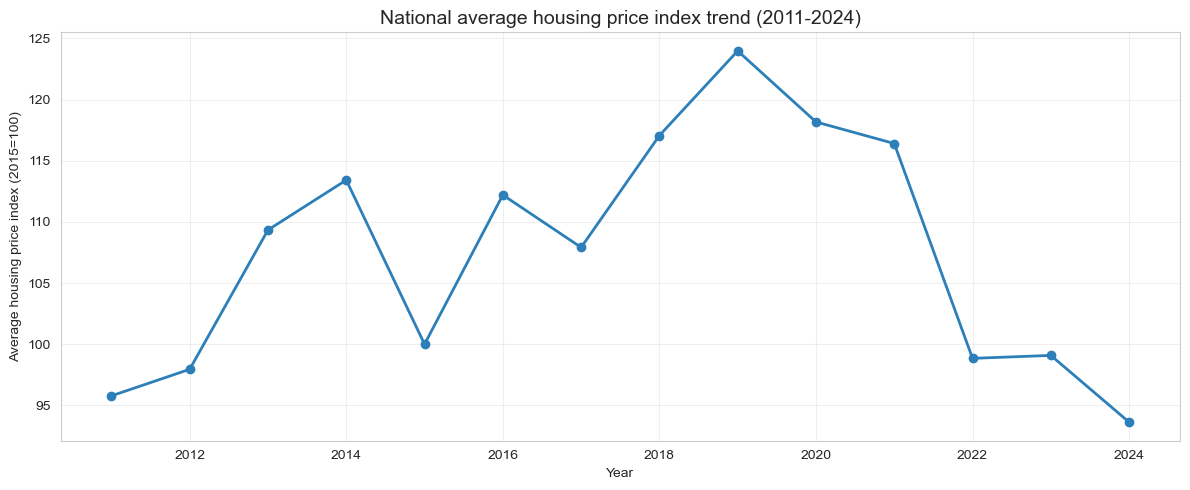

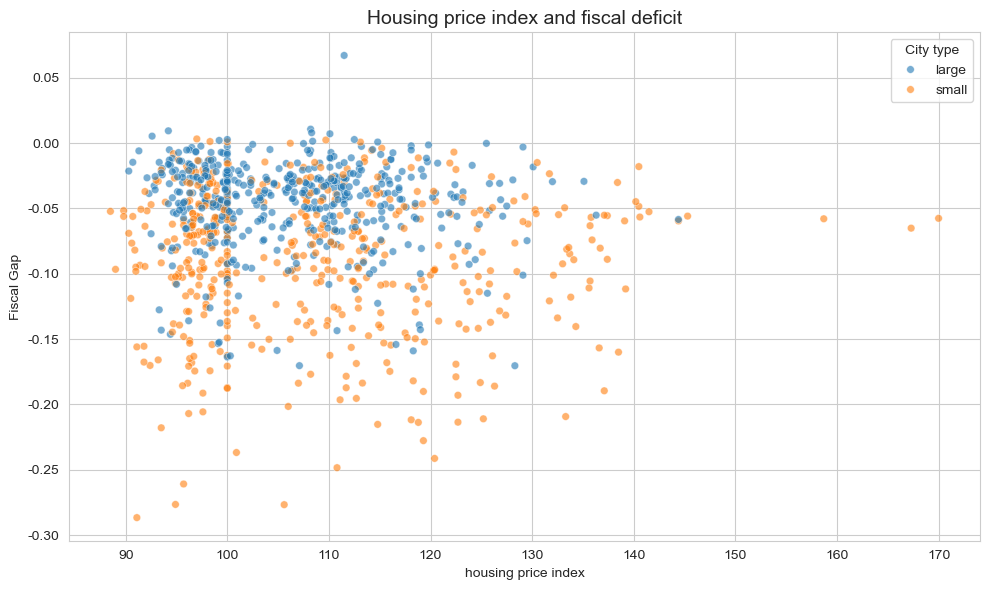

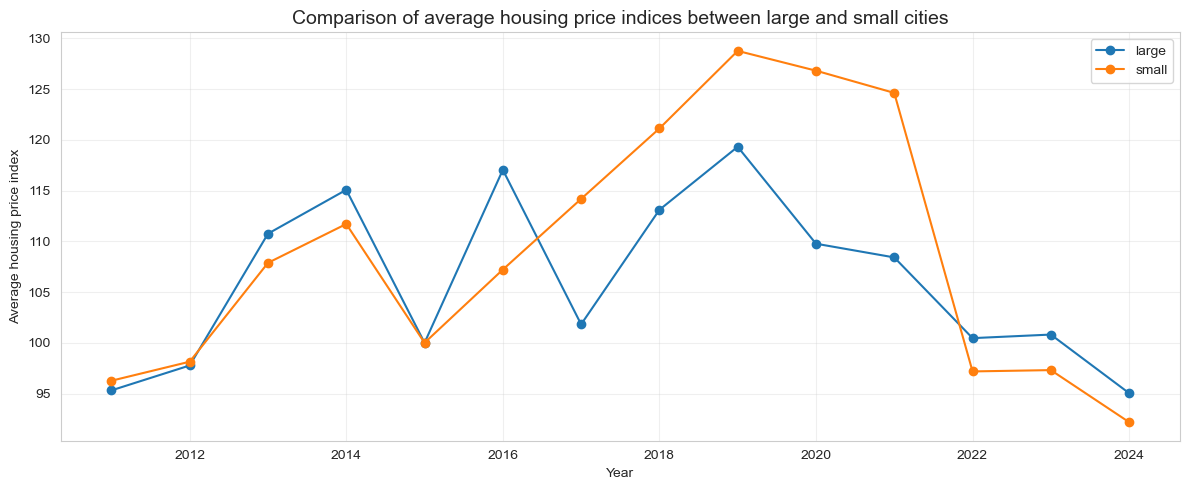

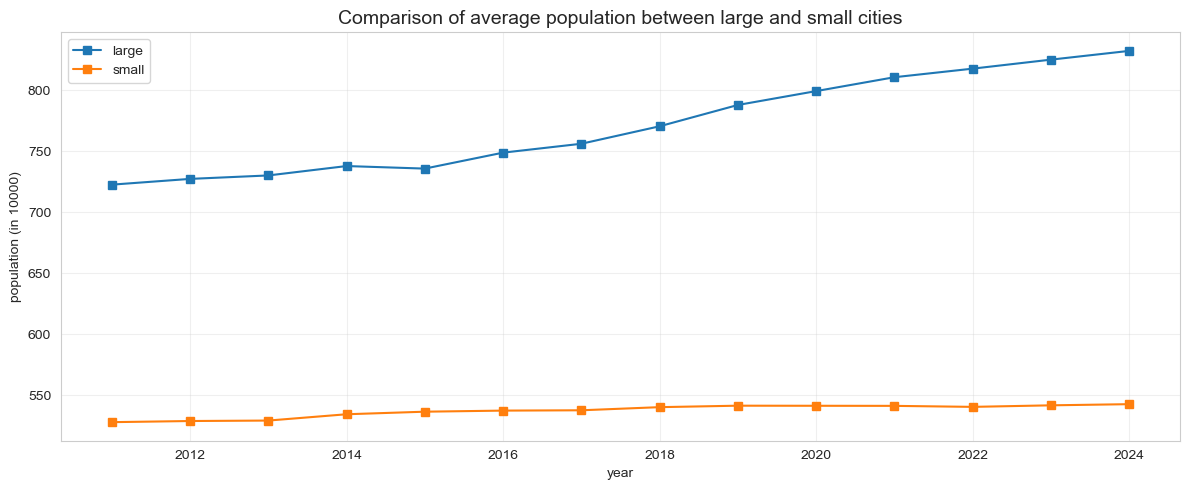

In [193]:
#graphs visualization
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial', 'PingFang SC']  # 用于中文显示
plt.rcParams['axes.unicode_minus'] = False


national_trend = df.groupby('year')['housing_price'].mean().reset_index()

plt.figure(figsize=(12, 5))
plt.plot(national_trend['year'], national_trend['housing_price'], marker='o', linewidth=2, color='#2c7fb8')
plt.title('National average housing price index trend (2011-2024)', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Average housing price index (2015=100)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='housing_price', y='fiscal_gap', hue='city_type', alpha=0.6, s=30)
plt.title('Housing price index and fiscal deficit', fontsize=14)
plt.xlabel('housing price index')
plt.ylabel('Fiscal Gap')
plt.legend(title='City type')
plt.tight_layout()
plt.show()


price_trend = df.groupby(['year', 'city_type'])['housing_price'].mean().reset_index()

plt.figure(figsize=(12, 5))
for typ in ['large', 'small']:
    subset = price_trend[price_trend['city_type'] == typ]
    plt.plot(subset['year'], subset['housing_price'], marker='o', label='large' if typ == 'large' else 'small')
plt.title('Comparison of average housing price indices between large and small cities', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Average housing price index')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


pop_trend = df.groupby(['year', 'city_type'])['户籍人口(万人)'].mean().reset_index()

plt.figure(figsize=(12, 5))
for typ in ['large', 'small']:
    subset = pop_trend[pop_trend['city_type'] == typ]
    plt.plot(subset['year'], subset['户籍人口(万人)'], marker='s', label='large' if typ == 'large' else 'small')
plt.title('Comparison of average population between large and small cities', fontsize=14)
plt.xlabel('year')
plt.ylabel('population (in 10000)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

